<a href="https://colab.research.google.com/github/crazair/ML_Course/blob/main/Lecture5_IntroDL_CV/PT_DL_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание

В этом домашнем задании вы обучите полносвязную нейронную сеть для решения задачи классификации на датасете CIFAR-10.

Это домашнее задание оформлено в не совсем традиционном формате. Не хочется заставлять вас копировать код. Вы будете менять уже существующую архитектуру, а затем отвечать на вопросы.

## Задание 1

Запустите данный изначально код и замерьте качество (accuracy) на тестовых данных.

**Ответ:
Accuracy of the network on the test images: 48.83 %**


## Задание 2

Добавьте еще один полносвязный слой (перед выходным) из 100 нейронов + функцию активации ReLU и запустите обучение. Замерьте accuracy на тесте.


**Ответ:
Accuracy of the network on the test images: 51.53 %**


## Задание 3

Теперь обучите полносвязную сеть с несколькими линейными слоями с числом нейронов: 1024, 512, 256, 128, 64 соответственно + функцией ReLU на выходе из каждого внутреннего слоя. Замерьте accuracy.

**Ответ:
Accuracy of the network on the test images: 53.8 %**

## Задание 4

К архитектуре из предыдущего задания добавьте Dropout(0.2) перед слоями из 1024 и 256 нейронов. Увеличилась ли accuracy по сравнению с предыдущим заданием?

*P.S. Спросите у ChatGPT, что такое Dropout? Зачем он нужен?*

**Ответ:
Accuracy of the network on the test images: 51.99 %**

Dropout — это метод регуляризации, при котором во время обучения случайно отключается часть нейронов. Это нужно для того, чтобы сеть не переобучалась, не запоминала обучающие данные слишком точно и лучше работала на новых данных.

## Задание 5

Уберите Dropout, но добавьте BatchNorm перед входом в те же линейные слои. Увеличилась ли accuracy по сравнению с заданием 3?

*P.S. Спросите у ChatGPT, что такое BatchNorm? Зачем он нужен?*

**Ответ:
Accuracy of the network on the test images: 51.47 %**

BatchNorm — это слой нормализации, который приводит значения признаков к более стабильному виду внутри батча. Это нужно для того, чтобы обучение проходило быстрее и устойчивее, а модель легче сходилась.

## Задание 6

Теперь пробуйте что угодно:
* разное число линейных слоев
* разные функции активации (вместо ReLU)
* комбинации Dropout / BatchNorm
* наконец, попробуйте написать сверточную нейронную сеть! :)

Цель - добиться наибольшей accuracy на тесте.

In [137]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np

def seed():
  np.random.seed(0)
  random.seed(0)
  torch.manual_seed(0)

seed()

In [138]:
# Check Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Hyper-parameters
input_size = 3072
num_classes = 10
num_epochs = 10 #1. Увеличим число эпох
batch_size = 32
learning_rate = 0.0005 #2. Уменьшаем learning_rate с 0.001

In [139]:
# MNIST dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                          train=False,
                                          transform=transform)

In [140]:
# Data loader
seed()
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [141]:
# Fully connected neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        seed()

        self.layers = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

model = NeuralNet(input_size, num_classes).to(device)

In [142]:
model

NeuralNet(
  (layers): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [143]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [144]:
seed()

loss_log = []

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.reshape(-1, 32*32*3).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprpagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))
            loss_log.append(loss.data.cpu().numpy())

Epoch [1/10], Step [100/1563], Loss: 2.2318
Epoch [1/10], Step [200/1563], Loss: 1.9391
Epoch [1/10], Step [300/1563], Loss: 1.6889
Epoch [1/10], Step [400/1563], Loss: 1.8432
Epoch [1/10], Step [500/1563], Loss: 1.8060
Epoch [1/10], Step [600/1563], Loss: 1.7103
Epoch [1/10], Step [700/1563], Loss: 1.5453
Epoch [1/10], Step [800/1563], Loss: 1.7121
Epoch [1/10], Step [900/1563], Loss: 1.5812
Epoch [1/10], Step [1000/1563], Loss: 1.3842
Epoch [1/10], Step [1100/1563], Loss: 1.7278
Epoch [1/10], Step [1200/1563], Loss: 1.6840
Epoch [1/10], Step [1300/1563], Loss: 1.6169
Epoch [1/10], Step [1400/1563], Loss: 1.5269
Epoch [1/10], Step [1500/1563], Loss: 1.4427
Epoch [2/10], Step [100/1563], Loss: 1.4687
Epoch [2/10], Step [200/1563], Loss: 1.2730
Epoch [2/10], Step [300/1563], Loss: 1.4652
Epoch [2/10], Step [400/1563], Loss: 1.5994
Epoch [2/10], Step [500/1563], Loss: 1.4748
Epoch [2/10], Step [600/1563], Loss: 1.7829
Epoch [2/10], Step [700/1563], Loss: 1.3029
Epoch [2/10], Step [800/15

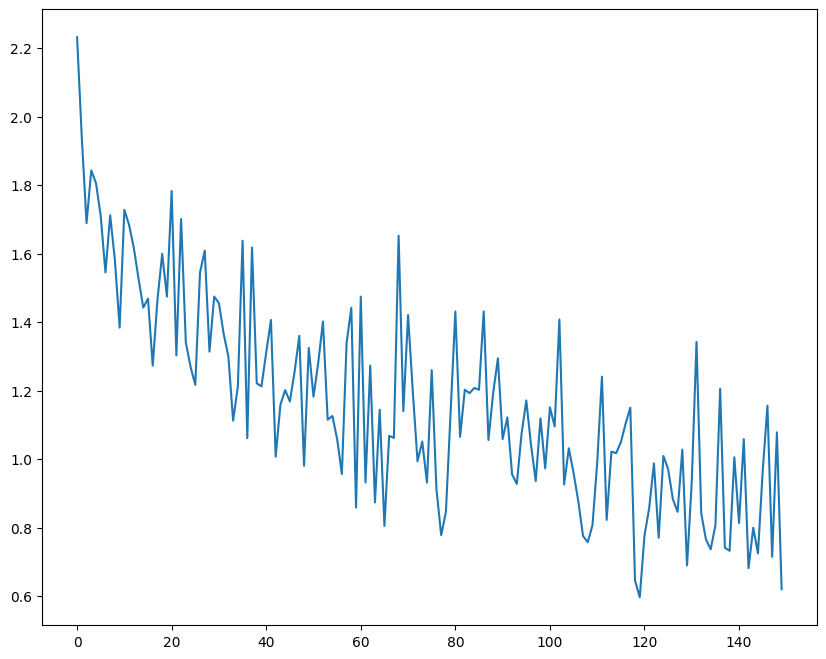

In [145]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,8))
plt.plot(loss_log)

In [146]:
seed()

# Test the model
# In the test phase, don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 32*32*3).to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Accuracy of the network on the test images: 53.84 %


Всего ошибок: 4383


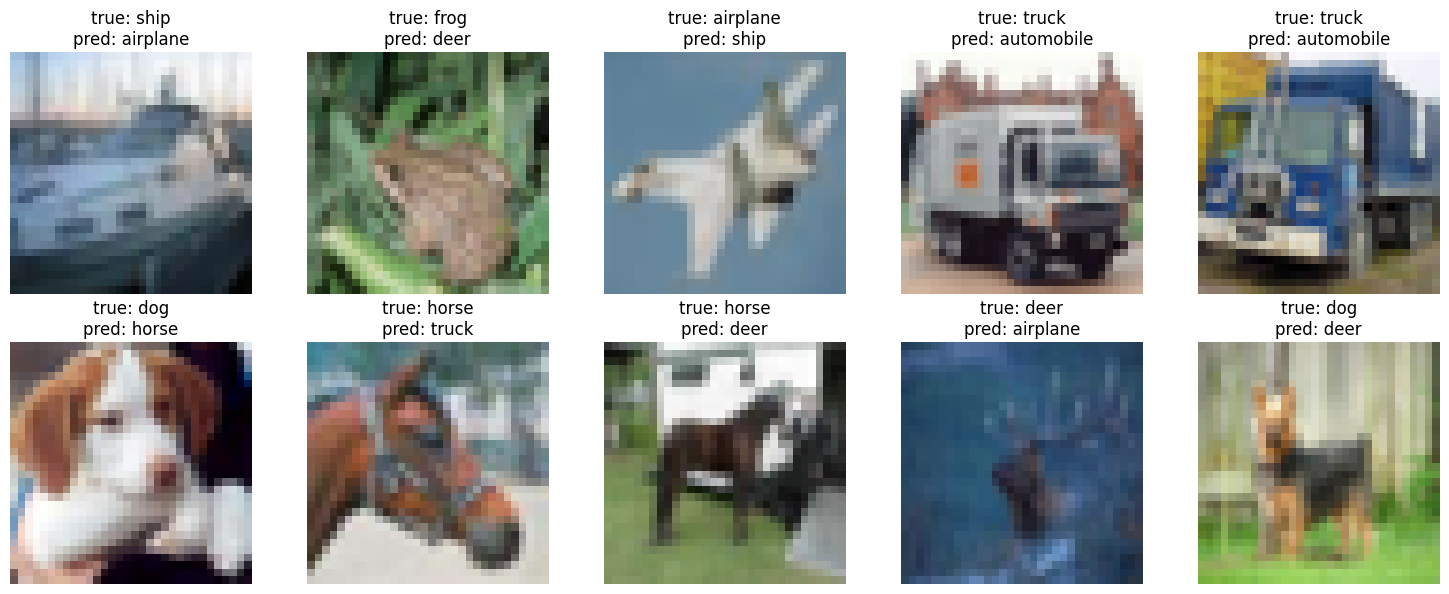

In [147]:
import matplotlib.pyplot as plt

# Названия классов CIFAR-10
classes = test_dataset.classes

# Соберем ошибочные предсказания
wrong_images = []
wrong_labels = []
wrong_preds = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_for_model = images.reshape(-1, 32 * 32 * 3).to(device)
        labels = labels.to(device)

        outputs = model(images_for_model)
        _, predicted = torch.max(outputs, 1)

        wrong_mask = predicted != labels

        if wrong_mask.any():
            wrong_images.extend(images[wrong_mask.cpu()])
            wrong_labels.extend(labels[wrong_mask].cpu())
            wrong_preds.extend(predicted[wrong_mask].cpu())

# Сколько показать
num_to_show = 10

print(f'Всего ошибок: {len(wrong_images)}')

plt.figure(figsize=(15, 6))
for i in range(min(num_to_show, len(wrong_images))):
    img = wrong_images[i]

    # denormalize: из [-1, 1] обратно примерно в [0, 1]
    img = img * 0.5 + 0.5

    # [C, H, W] -> [H, W, C]
    img = img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"true: {classes[wrong_labels[i]]}\npred: {classes[wrong_preds[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()